# Same anomaly but different scores

In [1]:
import os

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd

from anomaly.plot import add_line_indicators
from anomaly.plot import spec_photo_thumbnail
from anomaly.utils import specobjid_to_idx
from anomaly.utils import get_sdss_spec_img

from astroExplain.spectra import clustering
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

## Lime weights

In [2]:
def load_xai(n_segments: int, run_ids: dict, load_from: str):

    anomalies_arr = np.load(f"{load_from}/spectra_anomalies.npy", mmap_mode="r")
    specobjids_arr = np.load(f"{load_from}/specobjids_anomalies.npy", mmap_mode="r")
    weights = np.load(f"{load_from}/explanation_array_{run_id}.npy", mmap_mode="r")
    return anomalies_arr, specobjids_arr, weights

In [3]:
def weights_prep(weights, n_segments):
    """
    Function to prepare the weights data for clustering.
    """

    data_dict = {
        "weights": weights.copy(),
        "norm_weights": None,
        "unique_weights": None,
        "norm_unique_weights": None,
    }

    data_dict["norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["weights"]
    )

    data_dict["unique_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["weights"], n_segments=n_segments
    )

    data_dict["norm_unique_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["unique_weights"]
    )

    return data_dict

## Plot 5X2 explanations

In [4]:
def plot_same_anomaly_explanations(
    data: dict,
    wave_nm: np.ndarray,
    image: np.ndarray,
    line_configs: dict,
    spec_ylim,
    spec_yticks,
    xai_config: dict = {"y_lim": (0, 1.35), "y_ticks": [0, 0.5, 1]},
    text_dict={"x": 0.01, "y": 0.9, "ha": "left", "va": "center"},
    bbox_to_anchor=(0.695, 0.52, 0.5, 0.5),
    figsize=(14, 8.75),
    lw_dict: dict = {"spec": 0.75, "xai": 0.75},
):

    spectrum = data["spectrum"]

    fig, axs = plt.subplots(6, 2, sharex=True, figsize=figsize)

    # Map the scores to their respective rows and columns
    scores_layout = [
        ("SE", "RSE"),  # Row 1
        ("Filter SE", "Filter RSE"),  # Row 2
        ("Trim SE", "Trim RSE"),  # Row 3
        ("Filter + Trim SE", "Filter + Trim RSE"),  # Row 4
        ("LOF", "iForest"),  # Row 5
    ]

    # =================================================================================
    # Plot Row 0: Original Spectrum (Both Columns)
    # =================================================================================
    for c in [0, 1]:

        axs[0, c], _ = spec_photo_thumbnail(
            axs[0, c],
            wave_nm,
            spectrum,
            image,
            add_image=True,
            bbox_to_anchor=bbox_to_anchor,
            lw=lw_dict["spec"],
        )
        axs[0, c].set_ylim(spec_ylim)
        if spec_yticks is not None:
            axs[0, c].set_yticks(spec_yticks)
        axs[0, c].minorticks_on()

        if c == 0:
            axs[0, c].set_ylabel("Flux")
        else:
            axs[0, c].tick_params(labelleft=False)

        if line_configs.get("spectrum", {}).get("active_lines"):
            add_line_indicators(
                axs[0, c], wave_nm, spectrum, **line_configs["spectrum"]
            )

    # ================================================================================
    # Rows 1-4: Explanations
    # ================================================================================
    for i, (score_se_lof, score_rse_iforest) in enumerate(scores_layout):
        # Offset by 1 because Row 0 is the spectrum
        r = i + 1
        # Iterate through Col 0 (SE+lof) and Col 1 (RSE+iforest)
        for c, score_name in enumerate((score_se_lof, score_rse_iforest)):

            axs[r, c], _ = spec_photo_thumbnail(
                axs[r, c], wave_nm, data[score_name], add_image=False, lw=lw_dict["xai"]
            )

            axs[r, c].set_ylim(xai_config["y_lim"])
            axs[r, c].set_yticks(xai_config["y_ticks"])
            axs[r, c].minorticks_on()
            axs[r, c].text(
                text_dict["x"],
                text_dict["y"],
                score_name,
                ha=text_dict["ha"],
                va=text_dict["va"],
                transform=axs[r, c].transAxes,
            )

            if c == 0:
                axs[r, c].set_ylabel("Weights")
            else:
                axs[r, c].tick_params(labelleft=False)

            # Fetch the specific config for this score_name
            # If it doesn't exist in the dictionary, returns an empty dict {}
            current_config = line_configs.get(score_name, {})

            if current_config.get("active_lines"):
                add_line_indicators(
                    axs[r, c], wave_nm, data[score_name], **current_config
                )

    # ================================================================================
    # Global Axes Settings
    # ================================================================================
    wave_ticks = list(np.arange(400, 751, 50))
    for col in [0, 1]:
        axs[5, col].set_xlim(350, 770)
        axs[5, col].set_xticks(wave_ticks)
        axs[5, col].set_xlabel(r"$\lambda$ [nm]")
    return fig, axs

# Config

## Constants

### score map

In [8]:
score_name_map = {
    "mse": "SE",
    "mse_filter_250": "Filter SE",
    "mse_97": "Trim SE",
    "mse_filter_250_97": "Filter + Trim SE",
    "mse_rel": "RSE",
    "mse_filter_250_rel": "Filter RSE",
    "mse_97_rel": "Trim RSE",
    "mse_filter_250_97_rel": "Filter + Trim RSE",
    "lof": "LOF",
    "iforest": "iForest"
}

### run ids 221

In [9]:
run_ids_221_dict = {
    "mse": "xai_202607061319_uniform_221_samples_50000_scale_0.9",
    "mse_filter_250": "xai_202607061811_uniform_221_samples_50000_scale_0.9",
    "mse_97": "xai_202607061937_uniform_221_samples_50000_scale_0.9",
    "mse_filter_250_97": "xai_202607062045_uniform_221_samples_50000_scale_0.9",
    # ----
    "mse_rel": "xai_202607062150_uniform_221_samples_50000_scale_0.9",
    "mse_filter_250_rel": "xai_202607070126_uniform_221_samples_50000_scale_0.9",
    "mse_97_rel": "xai_202607062313_uniform_221_samples_50000_scale_0.9",
    "mse_filter_250_97_rel": "xai_202607071050_uniform_221_samples_50000_scale_0.9",
    # ----
    'lof': 'xai_202606221052_uniform_221_samples_50000_scale_0.9',
    'iforest': 'xai_202606222135_uniform_221_samples_50000_scale_0.9',
}

### run ids 243

In [10]:
run_ids_343_dict = {
    'mse': 'xai_202607141207_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250': 'xai_202607141314_uniform_343_samples_50000_scale_0.9',
    'mse_97': 'xai_202607141911_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97': 'xai_202607142055_uniform_343_samples_50000_scale_0.9',
    # ---
    'mse_rel': 'xai_202607132221_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_rel': 'xai_202607132326_uniform_343_samples_50000_scale_0.9',
    'mse_97_rel': 'xai_202607140125_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97_rel': 'xai_202607141022_uniform_343_samples_50000_scale_0.9',
    # ----
    'lof': 'xai_202607150029_uniform_343_samples_50000_scale_0.9',
    'iforest': 'xai_202607142229_uniform_343_samples_50000_scale_0.9',
}

### common ids

In [11]:
common_ids_list = [
    1767703038748813312,
    3146893614714480640,
    2504067977276581888,
    2987116977425770496,
    2383573327655495680,
    2254061567337326592,
    1189119947666647040,
    863589730464327680,
    1574045231064573952,
    320963969202284544,
    2430920226066425856,
    1455939533907453952,
    3090596414779058176,
    2034651834802530304,
    1554883216337299456,
    3131300885582342144,
    3134625263401330688,
    717229338335930368,
    507921902363240448,
    1083178151623813120,
    2027806000211322880,
    1969293001633064960,
    465049193757566976,
    465054141559891968,
    496660703600470016,
    315304777518966784,
    1058437216692365312,
    880459813388052480,
    1194687872486107136,
    2012065122054334464,
    2260957154544478208,
    2492775717629093888,
    2393747653117634560,
    2989429249607231488,
    2920606418660780032,
    3092927654341404672,
    2506362108355045376,
    2642523703153289216,
    2568209910483412992,
    2930814289679771648,
    2925222719152744448,
    2037927823305369600,
    2276661485063137280,
    1369264481594533888,
    461678641802143744,
    834368559839733760,
    2019902991347247104,
    3240389759704524800,
    528189200281921536,
    728630455640811520,
    847828505839298560,
    2814805362538997760,
    1499824066897405952,
    734111514142730240,
    2083037486723917824,
    1070735524563544064,
    1959124163192973312,
    305239577747023872,
    2347578053393147904,
    2723563214087415808,
    1315165211342170112,
    2379188189551159296,
    2824998659995756544,
    2829471472643237888,
    2401692176447727616,
    2490533538458265600,
    3130016111127455744,
    2918423338340608000,
    372686377910822912,
    2996194550038423552,
    1566200210080688128,
    2811439757043722240,
    746550839061014528,
    1171034355074623488,
    2006491952928811008,
    438045462621087744,
    393105946882107392,
    561847176611784704,
    2561555391200651264,
    516928552130603008,
    1119282266950887424,
    1022324576928950272,
    1593224832642738176,
    540591142962489344,
    665478622001260544,
    1480717578631407616,
    2274396484466141184,
    619262573816080384,
    969534273977608192,
    1633733043925575680,
    1921938144194750464,
    1638227297234348032,
    483014114227021824,
    2217020943266506752,
    471754291514730496,
    1538002139001939968,
    1935588031146780672,
    2245159102839810048,
    2286715969495656448,
    1919783100783552512,
    1820662115191515136,
    2942066691711985664,
    576552594944583680,
    1071977423131666432,
    532693075055634432
]

## Directories

In [12]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
explanations_dir = f"{data_dir}/explanations"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
ch_5_dir = f"{thesis_dir}/chapters/05_figures"

# Data

In [13]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")
bin_id = "bin_03"

In [14]:
lof_score_name = "lof_scores_bin_03_n60_manhattan.csv"
lof_scores_df = pd.read_csv(
    f"{latent_dir}/{bin_id}/lof/{lof_score_name}", index_col="specobjid"
)
# map rank col to lof_rank
lof_scores_df.rename(columns={"rank": "rank_lof"}, inplace=True)

iforest_score_name = "iforest_scores_bin_03_s128_e300_f100.csv"
iforest_scores_df = pd.read_csv(
    f"{latent_dir}/{bin_id}/iforest/{iforest_score_name}", index_col="specobjid"
)

# map rank col to iforest_rank
iforest_scores_df.rename(
    columns={"rank": "rank_iforest", "iforest_score": "iforest"}, inplace=True
)

# Explanations

In [15]:
bin_id = "bin_03"
n_segments = 343

if n_segments == 221:
    run_ids_dict = run_ids_221_dict
elif n_segments == 343:
    run_ids_dict = run_ids_343_dict

anomalies_all_dict = {}
specids_all_dict = {}
weights_all_dict = {}

for score_name, run_id in run_ids_dict.items():

    load_from = f"{explanations_dir}/{bin_id}/{score_name}"

    (
        anomalies_arr,
        specobjids_arr,
        weights_dict,
    ) = load_xai(n_segments=n_segments, run_ids=run_id, load_from=load_from)

    anomalies_all_dict[score_name] = anomalies_arr
    specids_all_dict[score_name] = specobjids_arr
    weights_all_dict[score_name] = weights_prep(
        weights=weights_dict, n_segments=n_segments
    )

In [16]:
np.sum(weights_all_dict['iforest']['norm_weights'][0]**2)

np.float32(1.0000001)

# Figures all common

```python
bin_id = "bin_03"

all_common_dict = {}

for objid in common_ids_list:
    rank_lof = lof_scores_df.loc[objid, "rank_lof"]
    rank_lof = f"{rank_lof:04d}"
    all_common_dict[rank_lof] = objid

spec_all_common_dict = {}
# dict with all explanations: xai_common_dict[anomaly_name][score_name] = weights
xai_all_common_dict = {}

print("Get specs and load photometry")

save_to = "/home/elom/Downloads/xai_common"

if not os.path.exists(save_to):
    os.makedirs(save_to)

for anomaly_name, specobjid in all_common_dict.items():

    # print(f"Processing anomaly: {anomaly_name}")
    idx_spectrum = specobjid_to_idx(specobjid, idx_id_spec)

    xai_all_common_dict[anomaly_name] = {}
    xai_all_common_dict[anomaly_name]["spectrum"] = spectra[idx_spectrum]

    for metric, score_name in score_name_map.items():

        idx_mask = specids_all_dict[metric] == specobjid

        _weights = weights_all_dict[metric]["norm_weights"][idx_mask][0]
        xai_all_common_dict[anomaly_name][score_name] = _weights

    # # download image and spectrum
    # ra, dec = final_meta_df[['ra', 'dec']].loc[specobjid].values
    # get_sdss_spec_img(
    #     specobjid=specobjid, ra=ra, dec=dec, save_to=save_to
    # )

# Load photometry
img_all_common_dict = {}

for key in all_common_dict.keys():

    objid = all_common_dict[key]
    img_name = f"image_{objid}.jpeg"
    img_ = mpimg.imread(f"{save_to}/{img_name}")
    img_all_common_dict[key] = img_
```

```python
save_dir = f"/home/elom/Downloads/unit_xai_common_{n_segments}"
os.makedirs(save_dir, exist_ok=True)
xai_config = {"y_lim": (0, 0.35), "y_ticks": [0, 0.1, 0.2, 0.3]}

for anomaly_name, specobjid in all_common_dict.items():
    plt.ioff()
    data = xai_all_common_dict[anomaly_name]
    spectrum = data["spectrum"]
    image = img_all_common_dict[anomaly_name]
    spec_ylim = None
    spec_yticks = None
    lw_dict: dict = {"spec": 0.75, "xai": 0.75}
    # Base configuration for explanations
    base_exp_config = {
        "indicator_starts": 0.06,
        "indicator_height": 0.07,
        "delta": 1,
        "fontsize": 6.5,
    }
    # lines to the spectrum and to each score
    line_configs = {
        "spectrum": {
            "indicator_starts": 5,
            "indicator_height": 5,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [],
        },
        # line indicators for explanations
        "SE": {
            **base_exp_config,
            "active_lines": [],
        },
        "Filter SE": {
            **base_exp_config,
            "active_lines": [],
        },
        "Trim SE": {
            **base_exp_config,
            "active_lines": [],
        },
        "Filter + Trim SE": {
            **base_exp_config,
            "active_lines": [],
        },
        "LOF": {**base_exp_config, "active_lines": [""]},
        "RSE": {**base_exp_config, "active_lines": [""]},
        "Filter RSE": {**base_exp_config, "active_lines": []},
        "Trim RSE": {
            **base_exp_config,
            "active_lines": [],
        },
        "Filter + Trim RSE": {
            **base_exp_config,
            "active_lines": [],
        },
        "iForest": {**base_exp_config, "active_lines": []},
    }

    fig, axs = plot_same_anomaly_explanations(
        data=data,
        wave_nm=wave_nm,
        image=image,
        line_configs=line_configs,
        spec_ylim=spec_ylim,
        spec_yticks=spec_yticks,
        xai_config=xai_config,
        lw_dict=lw_dict,
    )

    fname = f"{anomaly_name}_{specobjid}.jpeg"
    plt.subplots_adjust(hspace=0.06, wspace=0.02)

    fig.savefig(f"{save_dir}/{fname}", bbox_inches="tight")
    plt.close(fig)
```

# Data prep

In [ ]:
# specobjid = 1538002139001939968  # narrow line
# specobjid = 1633733043925575680  # broad line
# specobjid = 315304777518966784  # has HeI and NeIII
# specobjid = 1921938144194750464  # broad and has HeI and NeIII
# specobjid = 516928552130603008  # broad strong OIII and has HeI and NeIII
# specobjid = 2037927823305369600  # mid-broad OIII < H beta and OII, strong balmer
# specobjid = 2925222719152744448  # weird with data processing artifact
# weird broad noisy with bad sky substraction and data processing artifact
# specobjid = 393105946882107392
# specobjid = 3134625263401330688  # broad with bad sky substraction

In [2]:
# narrow_line
# 	lof_rank: 06
# broad_line
# 	lof_rank: 07
# HeNe
# 	lof_rank: 18
# broad_HeNe
# 	lof_rank: 20
# broad_strong_OIII_HeNe
# 	lof_rank: 42
# broad_OIII_smaller_Hbeta_OII
# 	lof_rank: 52
# processing_artifact
# 	lof_rank: 268
# broad_noise_bad_sky_substraction_processing_artifact
# 	lof_rank: 496
# broad_bad_sky_substraction
# 	lof_rank: 1753

In [18]:
bin_id = "bin_03"

common_dict = {
    "narrow_line_1": 969534273977608192,
    "narrow_line": 1538002139001939968,
    "broad_line": 1633733043925575680,
    "HeNe": 315304777518966784,
    "broad_HeNe": 1921938144194750464,
    "broad_strong_OIII_HeNe": 516928552130603008,
    "broad_OIII_smaller_Hbeta_OII": 2037927823305369600,
    "processing_artifact": 2925222719152744448,
    "broad_noise_bad_sky_substraction_processing_artifact": 393105946882107392,
    "broad_bad_sky_substraction": 3134625263401330688
}

spec_common_dict = {}
# dict with all explanations: xai_common_dict[anomaly_name][score_name] = weights
xai_common_dict = {}

print("Get specs and load photometry")

save_to = f"{ch_5_dir}/{bin_id}/common_xai"

if not os.path.exists(save_to):
    os.makedirs(save_to)

for anomaly_name, specobjid in common_dict.items():

    print(f"Processing anomaly: {anomaly_name}")
    idx_spectrum = specobjid_to_idx(specobjid, idx_id_spec)

    xai_common_dict[anomaly_name] = {}
    xai_common_dict[anomaly_name]["spectrum"] = spectra[idx_spectrum]

    for metric, score_name in score_name_map.items():

        idx_mask = specids_all_dict[metric] == specobjid

        _weights = weights_all_dict[metric]["norm_weights"][idx_mask][0]
        xai_common_dict[anomaly_name][score_name] = _weights

    # # download image and spectrum
    # ra, dec = final_meta_df[['ra', 'dec']].loc[specobjid].values
    # get_sdss_spec_img(
    #     specobjid=specobjid, ra=ra, dec=dec, save_to=save_to
    # )

# Load photometry
img_common_dict = {}

for key in common_dict.keys():

    objid = common_dict[key]
    img_name = f"image_{objid}.jpeg"
    img_ = mpimg.imread(f"{save_to}/{img_name}")
    img_common_dict[key] = img_

Get specs and load photometry
Processing anomaly: narrow_line_1
Processing anomaly: narrow_line
Processing anomaly: broad_line
Processing anomaly: HeNe
Processing anomaly: broad_HeNe
Processing anomaly: broad_strong_OIII_HeNe
Processing anomaly: broad_OIII_smaller_Hbeta_OII
Processing anomaly: processing_artifact
Processing anomaly: broad_noise_bad_sky_substraction_processing_artifact
Processing anomaly: broad_bad_sky_substraction


# Narrow line

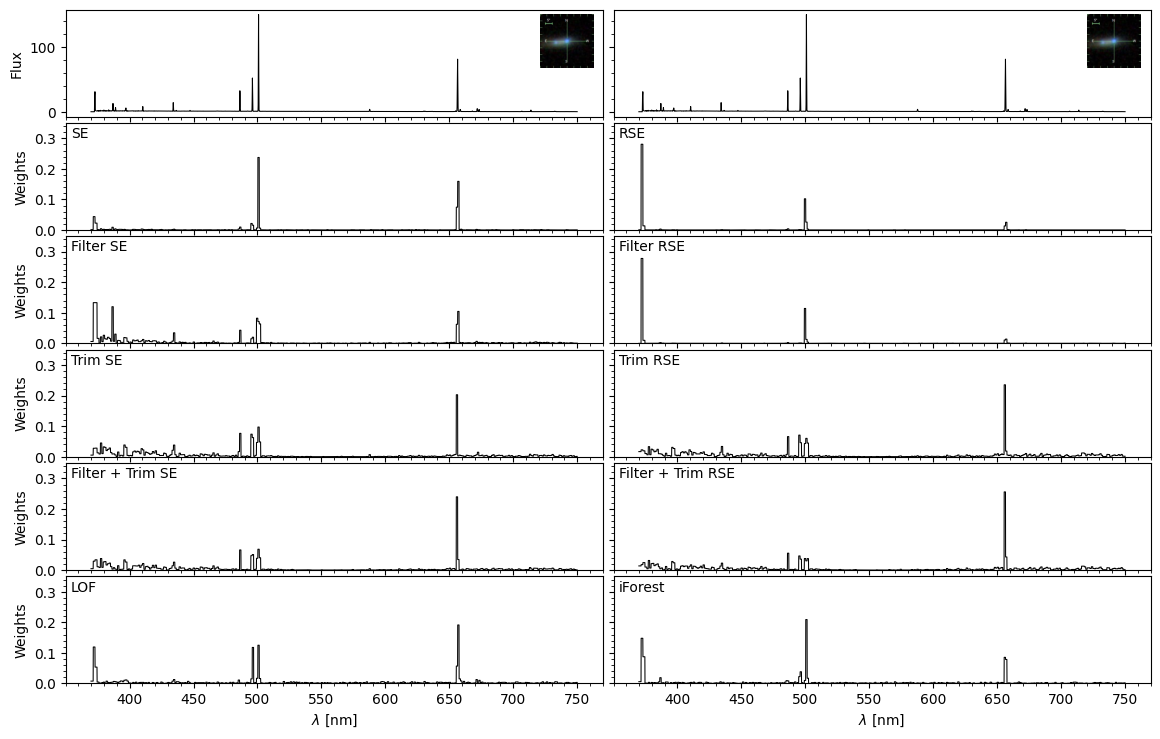

In [21]:
anomaly_name = "narrow_line"
data = xai_common_dict[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]
xai_config = {"y_lim": (0, 0.35), "y_ticks": [0, 0.1, 0.2, 0.3]}
# spec_ylim = (-5, 190)
# spec_yticks = range(0, 181, 60)
spec_ylim = None
spec_yticks = None
lw_dict: dict = {"spec": 0.75, "xai": 0.75}
# Base configuration for explanations
base_exp_config = {
    "indicator_starts": 0.06,
    "indicator_height": 0.07,
    "delta": 1,
    "fontsize": 6.5,
}
# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 5,
        "indicator_height": 5,
        "delta": 1,
        "fontsize": 6.5,
        "active_lines": [],
    },
    # line indicators for explanations
    "SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "LOF": {**base_exp_config, "active_lines": [""]},
    "RSE": {**base_exp_config, "active_lines": [""]},
    "Filter RSE": {**base_exp_config, "active_lines": []},
    "Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "iForest": {**base_exp_config, "active_lines": []},
}

fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
    lw_dict=lw_dict,
    image=image,
    xai_config=xai_config,
)

plt.subplots_adjust(hspace=0.06, wspace=0.02)

# broad_line

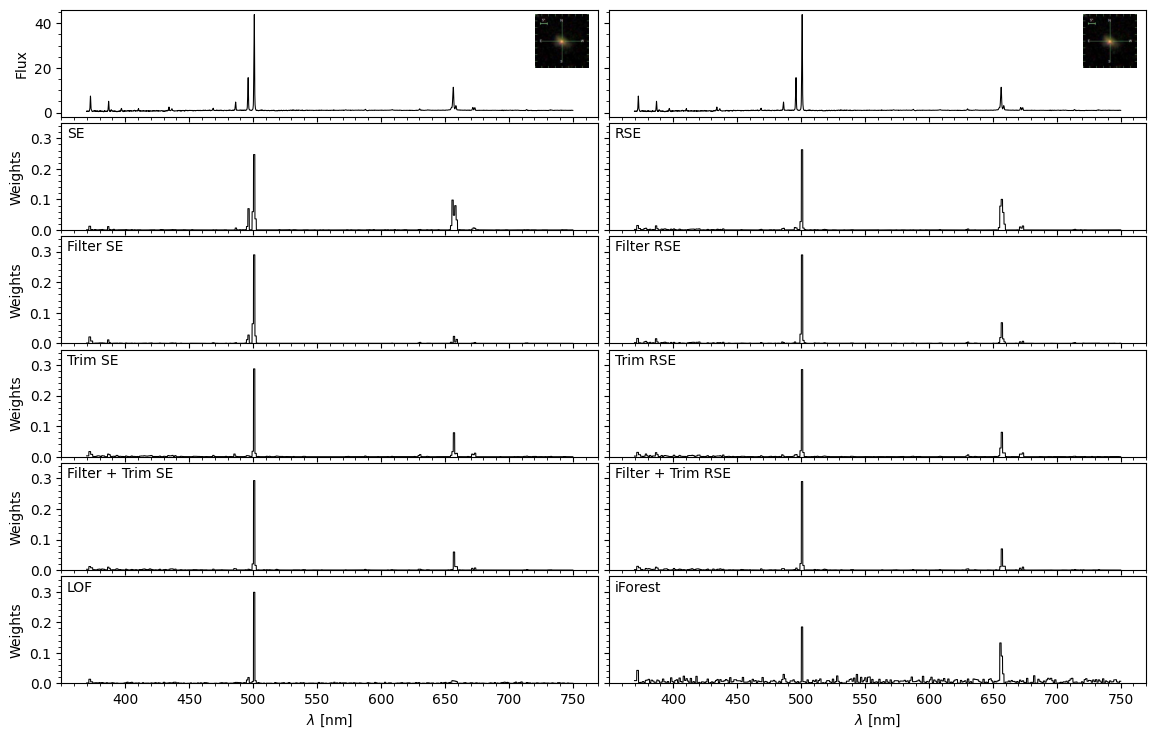

In [22]:
anomaly_name = "broad_line"
data = xai_common_dict[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]
xai_config = {"y_lim": (0, 0.35), "y_ticks": [0, 0.1, 0.2, 0.3]}
spec_ylim = None
spec_yticks = None
lw_dict: dict = {"spec": 0.75, "xai": 0.75}
# Base configuration for explanations
base_exp_config = {
    "indicator_starts": 0.06,
    "indicator_height": 0.07,
    "delta": 1,
    "fontsize": 6.5,
}
# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 5,
        "indicator_height": 5,
        "delta": 1,
        "fontsize": 6.5,
        "active_lines": [],
    },
    # line indicators for explanations
    "SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "LOF": {**base_exp_config, "active_lines": [""]},
    "RSE": {**base_exp_config, "active_lines": [""]},
    "Filter RSE": {**base_exp_config, "active_lines": []},
    "Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "iForest": {**base_exp_config, "active_lines": []},
}

fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
    lw_dict=lw_dict,
    image=image,
    xai_config=xai_config,
)

plt.subplots_adjust(hspace=0.06, wspace=0.02)

# HeNe

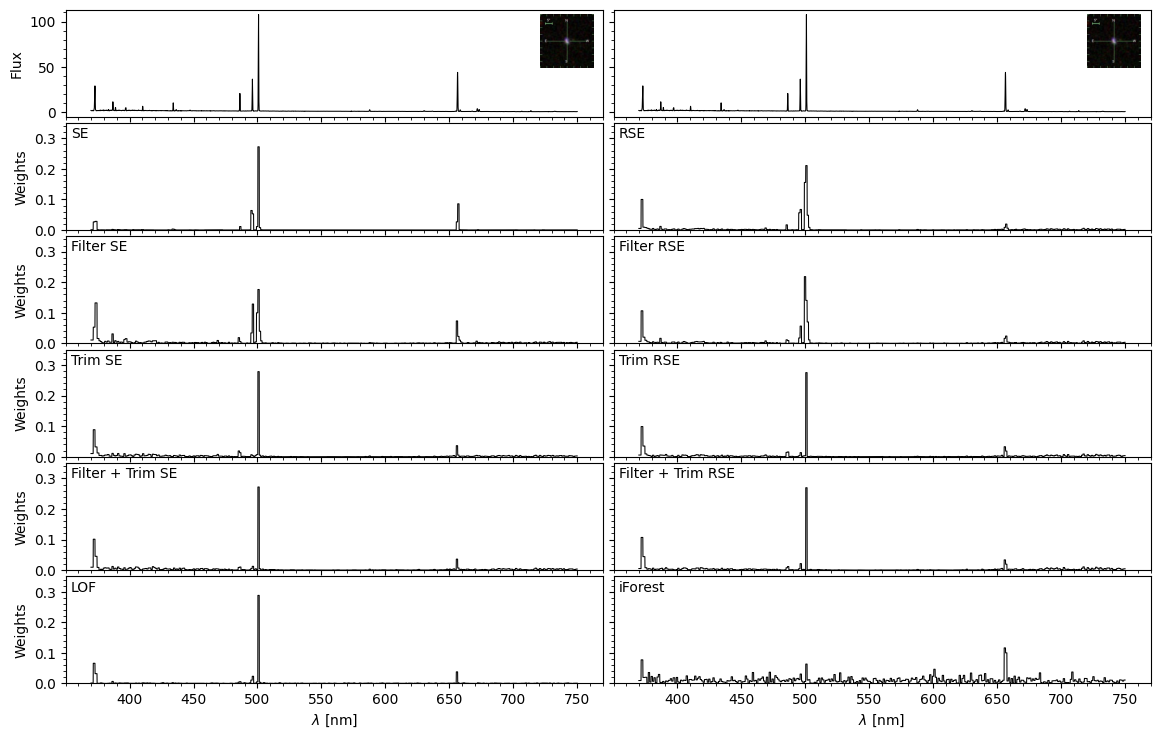

In [23]:
anomaly_name = "HeNe"
data = xai_common_dict[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]
xai_config = {"y_lim": (0, 0.35), "y_ticks": [0, 0.1, 0.2, 0.3]}
spec_ylim = None
spec_yticks = None
lw_dict: dict = {"spec": 0.75, "xai": 0.75}
# Base configuration for explanations
base_exp_config = {
    "indicator_starts": 0.06,
    "indicator_height": 0.07,
    "delta": 1,
    "fontsize": 6.5,
}
# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 5,
        "indicator_height": 5,
        "delta": 1,
        "fontsize": 6.5,
        "active_lines": [],
    },
    # line indicators for explanations
    "SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "LOF": {**base_exp_config, "active_lines": [""]},
    "RSE": {**base_exp_config, "active_lines": [""]},
    "Filter RSE": {**base_exp_config, "active_lines": []},
    "Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "iForest": {**base_exp_config, "active_lines": []},
}

fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
    lw_dict=lw_dict,
    image=image,
    xai_config=xai_config,
)

plt.subplots_adjust(hspace=0.06, wspace=0.02)

# broad_HeNe

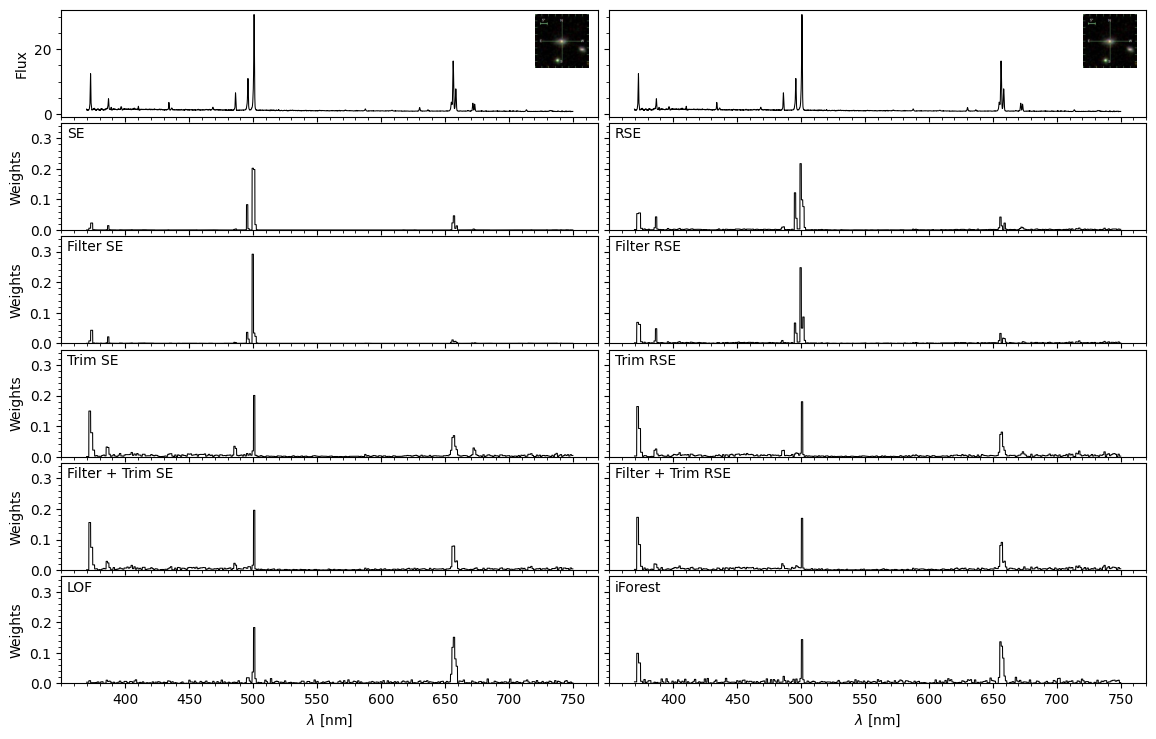

In [24]:
anomaly_name = "broad_HeNe"
data = xai_common_dict[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]
xai_config = {"y_lim": (0, 0.35), "y_ticks": [0, 0.1, 0.2, 0.3]}
spec_ylim = None
spec_yticks = None
lw_dict: dict = {"spec": 0.75, "xai": 0.75}
# Base configuration for explanations
base_exp_config = {
    "indicator_starts": 0.06,
    "indicator_height": 0.07,
    "delta": 1,
    "fontsize": 6.5,
}
# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 5,
        "indicator_height": 5,
        "delta": 1,
        "fontsize": 6.5,
        "active_lines": [],
    },
    # line indicators for explanations
    "SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "LOF": {**base_exp_config, "active_lines": [""]},
    "RSE": {**base_exp_config, "active_lines": [""]},
    "Filter RSE": {**base_exp_config, "active_lines": []},
    "Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "iForest": {**base_exp_config, "active_lines": []},
}

fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
    lw_dict=lw_dict,
    image=image,
    xai_config=xai_config,
)

plt.subplots_adjust(hspace=0.06, wspace=0.02)

# broad_strong_OIII_HeNe

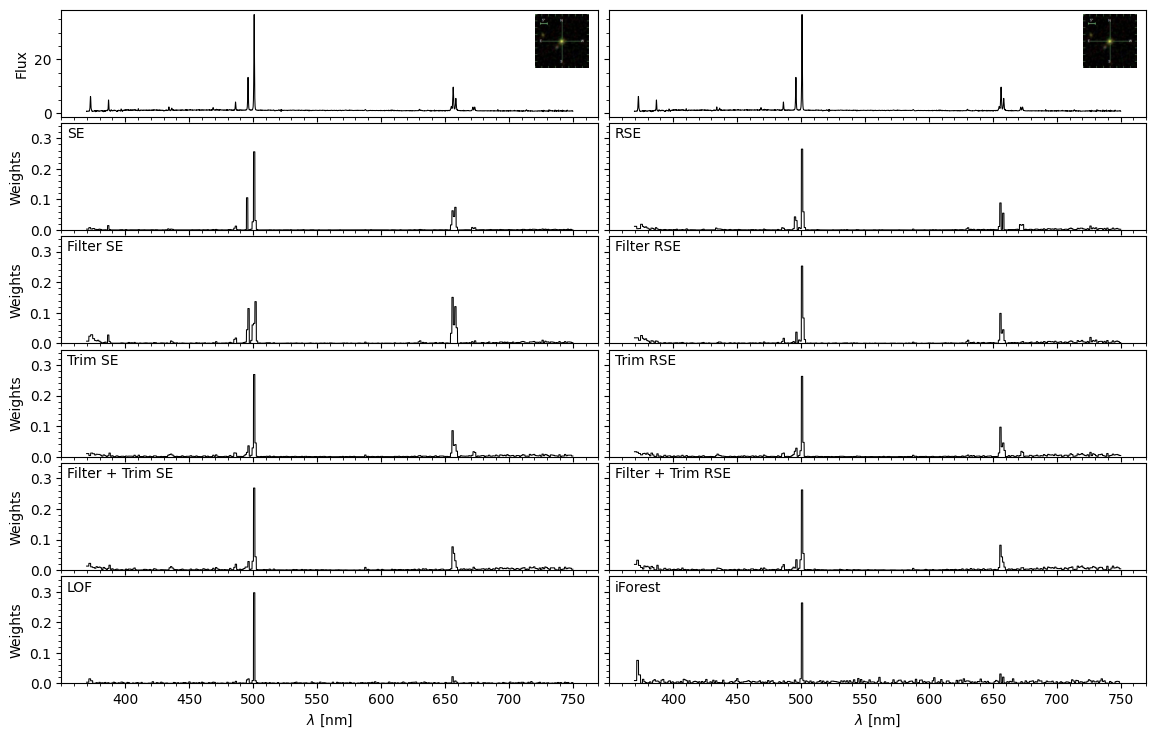

In [26]:
anomaly_name = "broad_strong_OIII_HeNe"
data = xai_common_dict[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]
xai_config = {"y_lim": (0, 0.35), "y_ticks": [0, 0.1, 0.2, 0.3]}
spec_ylim = None
spec_yticks = None
lw_dict: dict = {"spec": 0.75, "xai": 0.75}
# Base configuration for explanations
base_exp_config = {
    "indicator_starts": 0.06,
    "indicator_height": 0.07,
    "delta": 1,
    "fontsize": 6.5,
}
# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 5,
        "indicator_height": 5,
        "delta": 1,
        "fontsize": 6.5,
        "active_lines": [],
    },
    # line indicators for explanations
    "SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "LOF": {**base_exp_config, "active_lines": [""]},
    "RSE": {**base_exp_config, "active_lines": [""]},
    "Filter RSE": {**base_exp_config, "active_lines": []},
    "Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "iForest": {**base_exp_config, "active_lines": []},
}

fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
    lw_dict=lw_dict,
    image=image,
    xai_config=xai_config,
)

plt.subplots_adjust(hspace=0.06, wspace=0.02)

# broad_noise_bad_sky_substraction_processing_artifact

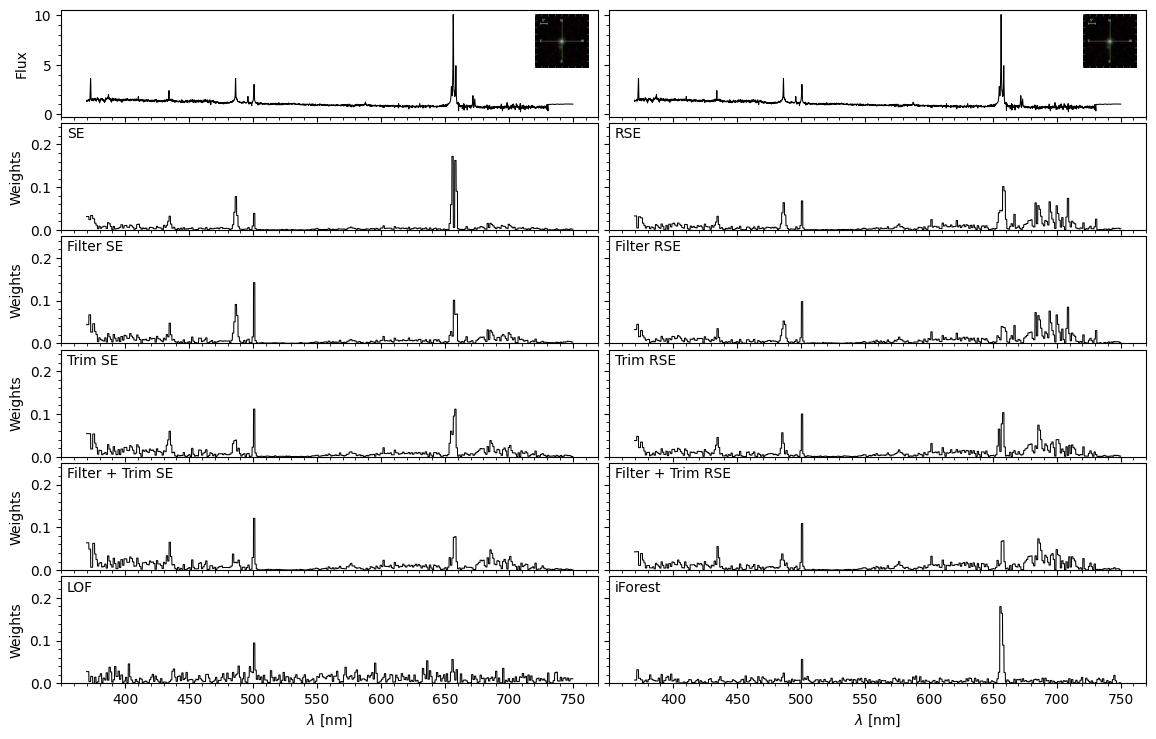

In [29]:
anomaly_name = "broad_noise_bad_sky_substraction_processing_artifact"
data = xai_common_dict[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]
xai_config = {"y_lim": (0, 0.25), "y_ticks": [0, 0.1, 0.2]}
spec_ylim = None
spec_yticks = None
lw_dict: dict = {"spec": 0.75, "xai": 0.75}
# Base configuration for explanations
base_exp_config = {
    "indicator_starts": 0.06,
    "indicator_height": 0.07,
    "delta": 1,
    "fontsize": 6.5,
}
# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 5,
        "indicator_height": 5,
        "delta": 1,
        "fontsize": 6.5,
        "active_lines": [],
    },
    # line indicators for explanations
    "SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "LOF": {**base_exp_config, "active_lines": [""]},
    "RSE": {**base_exp_config, "active_lines": [""]},
    "Filter RSE": {**base_exp_config, "active_lines": []},
    "Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "iForest": {**base_exp_config, "active_lines": []},
}

fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
    lw_dict=lw_dict,
    image=image,
    xai_config=xai_config,
)

plt.subplots_adjust(hspace=0.06, wspace=0.02)

# broad_bad_sky_substraction

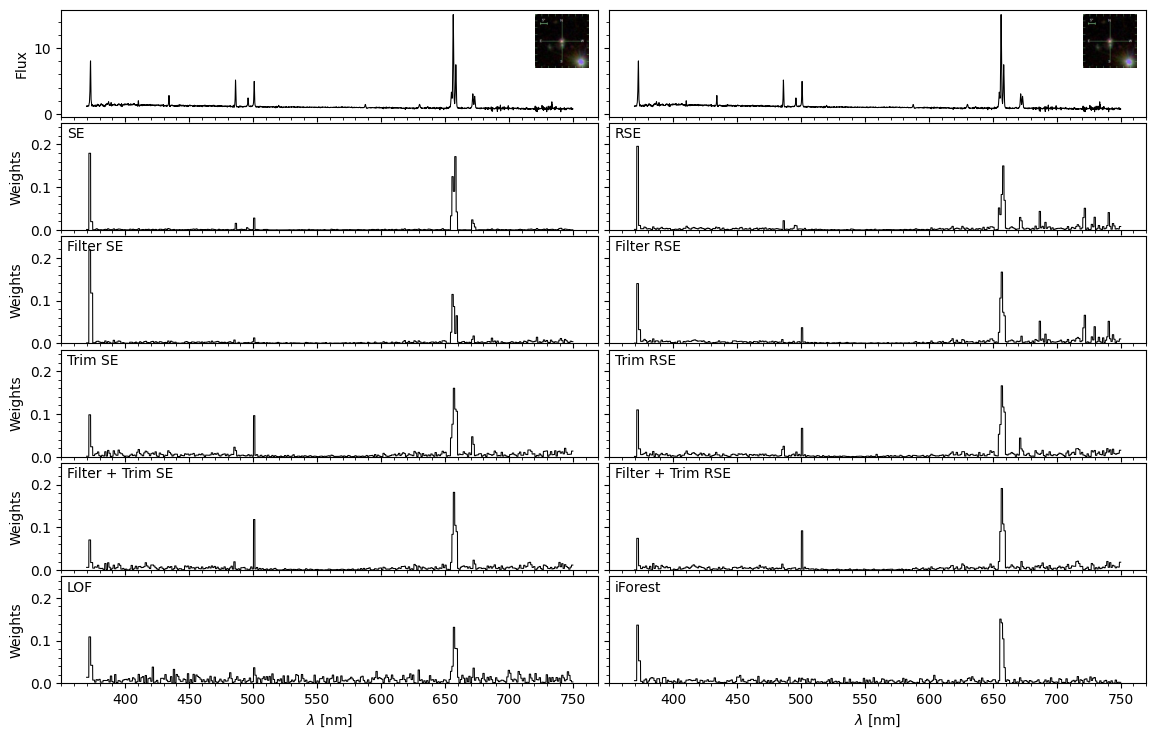

In [31]:
anomaly_name = "broad_bad_sky_substraction"
data = xai_common_dict[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]
xai_config = {"y_lim": (0, 0.25), "y_ticks": [0, 0.1, 0.2]}
spec_ylim = None
spec_yticks = None
lw_dict: dict = {"spec": 0.75, "xai": 0.75}
# Base configuration for explanations
base_exp_config = {
    "indicator_starts": 0.06,
    "indicator_height": 0.07,
    "delta": 1,
    "fontsize": 6.5,
}
# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 5,
        "indicator_height": 5,
        "delta": 1,
        "fontsize": 6.5,
        "active_lines": [],
    },
    # line indicators for explanations
    "SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "LOF": {**base_exp_config, "active_lines": [""]},
    "RSE": {**base_exp_config, "active_lines": [""]},
    "Filter RSE": {**base_exp_config, "active_lines": []},
    "Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "iForest": {**base_exp_config, "active_lines": []},
}

fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
    lw_dict=lw_dict,
    image=image,
    xai_config=xai_config,
)

plt.subplots_adjust(hspace=0.06, wspace=0.02)